# Assignment 6: Data Scraping
```
Course: ENV 700 - Environmental Data Exploration
Author: Lam Thieu
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Scraping**. We'll be scraping data from the North Carolina Department of Water Quality (NC DWQ). 

## 1. Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`) and any other packages you wish to use. 
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [1]:
#Import packages
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import time
from itertools import product

#Set Seaborn theme
sns.set_theme(style="darkgrid", context='notebook')

## 2. Scraping Water Supply Data 
We will be scraping data from the NC DEQs Local Water Supply Planning website, specifically the Durham's 2025 Municipal Local Water Supply Plan (LWSP): 
 * Navigate to https://www.ncwater.org/WUDC/app/LWSP/search.php
 * Set the year to 2025
 * Scroll down and select the LWSP link next to Durham Municipality. 
 * Note the web address: <https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025>

---
### 2.1 Retrieve the website and parse it using BeautifulSoup

In [2]:
# 2.1 Retrieve the website and parse it using BeautifulSoup
url = "https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025"

response = requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")
type(webpage)

if webpage.title: 
    print(webpage.title.get_text(strip=True))
else: print("No page title")

DWR :: Local Water Supply Planning


### 2.2 The data we want to collect are listed below:

* From the **1. System Information** section:
    - Water system name
    - Contact Person
    - Ownership
 
* From the **3. Water Supply Sources** section:
    - Maximum Day Use (MGD) - for each month

In the code chunk below scrape these values, assigning them to four separate variables.  
>HINT: The first value should be "`Durham`", the second "`Kieu Tran`", the third "`Municipality`", and the last should be a vector of 12 numeric values (represented as strings)".

In [3]:
# 2.2 Scrape the data into variables
water_system = webpage.select_one(
    "div+ table tr:nth-child(1) td:nth-child(2)"
).get_text(strip=True)

contact = webpage.select_one(
    "div+ table tr:nth-child(4) td:nth-child(2)"
).get_text(strip=True)

owner = webpage.select_one(
    "div+ table tr:nth-child(2) td:nth-child(4)"
).get_text(strip=True)


max_nodes = webpage.select(
    "th~ td+ td"
)
max_withdrawals = [node.get_text(strip=True) for node in max_nodes]


print(water_system)
print(contact)
print(owner)
print(max_withdrawals)

Durham
Kieu Tran
Municipality
['40.2400', '37.3800', '37.9100', '33.8100', '36.8400', '36.9000', '36.5300', '38.0400', '33.8000', '37.9500', '35.2000', '32.2000']


### 2.3 Construct a dataframe from the scraped data
Convert your scraped data into a dataframe. 
* This dataframe should have a column for each of the 4 variables scraped and a row for the month corresponding to the withdrawal data. 
* Note that you won't likely be able to scrape max water usage data in chronological order.
* Include columns for the month and year the data were collected. 
* Sort the data on year and month.
* Construct a datetime column from the year and month, assuming the day of the month will be the first. 

>🔥**TIP**: : To construct a list from a repeated set of values, use this approach:
>```python
>years_x6 = [2025] * 6
>print(years_x6)
>```

>🔥**TIP**: To construct a datetime column when you just the year and month, you can use the following:
>```python
>df['Date'] = pd.to_datetime({
>    "year": df['Year'],
>    "month": df['Month'],
>    "day": 1
>})
>```

In [4]:
# 2.3 Construct the dataframe from scraped data

month_order = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]

df_withdrawals = pd.DataFrame({
    "Month": month_order,
    "Year": 2025,
    "Max_Withdrawals_mgd": pd.to_numeric(max_withdrawals),
})


df_withdrawals = df_withdrawals.assign(
    Water_System_Name = water_system,
    Contact_person = contact,
    Ownership = owner,
    Date=lambda d: pd.to_datetime(dict(year=d["Year"], month=d["Month"], day=1)),
).sort_values("Date")

df_withdrawals

,Month,Year,Max_Withdrawals_mgd,Water_System_Name,Contact_person,Ownership,Date
0,1,2025,40.24,Durham,Kieu Tran,Municipality,2025-01-01
3,2,2025,33.81,Durham,Kieu Tran,Municipality,2025-02-01
6,3,2025,36.53,Durham,Kieu Tran,Municipality,2025-03-01
9,4,2025,37.95,Durham,Kieu Tran,Municipality,2025-04-01
1,5,2025,37.38,Durham,Kieu Tran,Municipality,2025-05-01
4,6,2025,36.84,Durham,Kieu Tran,Municipality,2025-06-01
7,7,2025,38.04,Durham,Kieu Tran,Municipality,2025-07-01
10,8,2025,35.20,Durham,Kieu Tran,Municipality,2025-08-01
2,9,2025,37.91,Durham,Kieu Tran,Municipality,2025-09-01
5,10,2025,36.90,Durham,Kieu Tran,Municipality,2025-10-01


### 2.4 Plot the data
* Create a line plot of the maximum daily withdrawals across the months for 2024
* Label the x-axis with month names or abbreviated month names. (Note, you may have to do some more wrangling...)

<Axes: title={'center': '2025 Water usage data for Durham\nMunicipality'}, xlabel='Date', ylabel='Withdrawal (mgd)'>

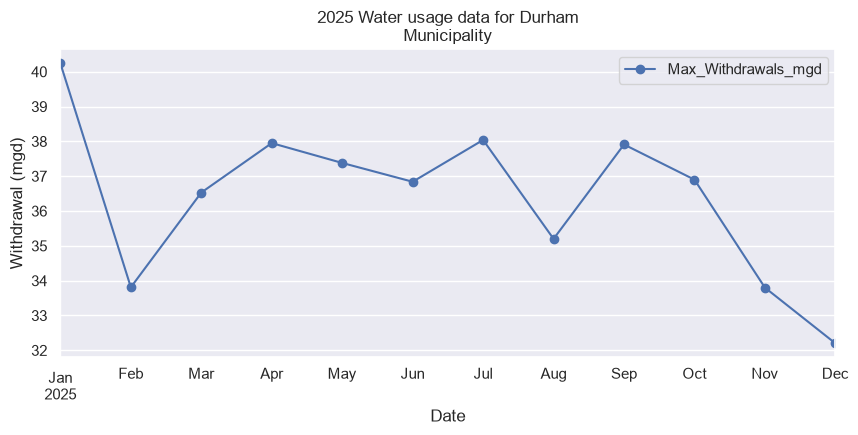

In [5]:
df_withdrawals.plot(kind='line',x='Date',y='Max_Withdrawals_mgd',figsize=(10,4),marker='o',
                     title=f"2025 Water usage data for {water_system}\n{owner}",
                     ylabel="Withdrawal (mgd)")

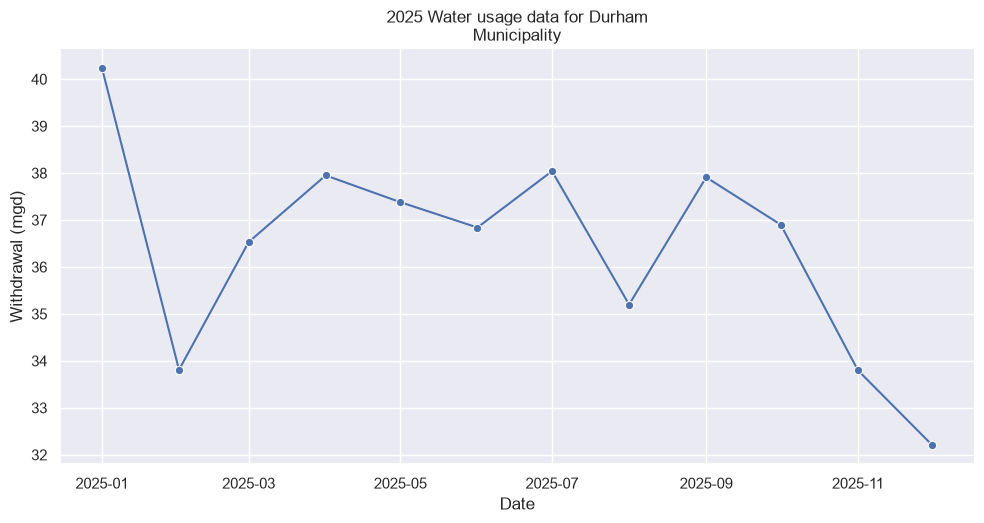

In [6]:
# 2.4 Plot the data

g = sns.relplot(
    data=df_withdrawals,
    x="Date",
    y="Max_Withdrawals_mgd",
    kind="line",
    marker="o",
    aspect=2
)
g.set(
    title=f"2025 Water usage data for {water_system}\n{owner}",
    xlabel="Date",
    ylabel="Withdrawal (mgd)",
);

## 3. Automating the Scraping Process
### 3.1 Construct the scraping function
Note that the PWSID and the year appear in the web address for the page we scraped. Construct a function with two inputs, "PWSID" and "year", that:
  - Creates a URL pointing to the LWSP for that PWSID for the given year
  - Creates a website object and scrapes the data from that object (just as you did above)
  - Constructs a dataframe from the scraped data, mostly as you did above, but includes the PWSID and year provided as function inputs in the dataframe. 
  - Returns the dataframe as the function's output

In [7]:
# 3.1 Create a scraping function



def scrape_withdrawals(PWSID, the_year, pause=0):
 """Scrape monthly max day use for one NC water system (PWSID) and year."""
 url = f"https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid={PWSID}&year={the_year}"
 response = requests.get(url)
 response.raise_for_status()
 the_website = BeautifulSoup(response.text, "html.parser")

    #Extract the data from the website object
 water_system = the_website.select_one("div+ table tr:nth-child(1) td:nth-child(2)").get_text(strip=True)
 contact = the_website.select_one("div+ table tr:nth-child(4) td:nth-child(2)").get_text(strip=True)
 owner = the_website.select_one("div+ table tr:nth-child(2) td:nth-child(4)").get_text(strip=True)
 withdrawals = [x.get_text(strip=True) for x in the_website.select("th~ td+ td")]

    #Wrangle into a dataframe
 month_order = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]
 df = pd.DataFrame({
        "Month": month_order,
        "PWSID": PWSID,
        "Year": the_year,
        "Max_Withdrawals_mgd": pd.to_numeric(withdrawals),
        "Water_System_Name": water_system,
        "Contact_Person": contact,
        "Ownership": owner,
    })
 df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
 df = df.sort_values("Date").reset_index(drop=True)

    #Pause before proceeding
 if pause: time.sleep(pause)

    #Return the dataframe
 return df

### 3.2 Fetch and plot data for Durham (PWSID=`03-32-010`) in 2020
* Use the function above to extract and plot max daily withdrawals for Durham (PWSID=`03-32-010`) for each month in 2020.
* Reveal the structure of your dataframe using the `info()` function. 
* Then create plot your data in a line plot as above: Max Usage by Month.

In [8]:
# 3.2.1 Scrape data for 03-32-010 in 2020 & display its structure
the_df = scrape_withdrawals("03-32-010", 2020)
the_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Month                12 non-null     int64         
 1   PWSID                12 non-null     str           
 2   Year                 12 non-null     int64         
 3   Max_Withdrawals_mgd  12 non-null     float64       
 4   Water_System_Name    12 non-null     str           
 5   Contact_Person       12 non-null     str           
 6   Ownership            12 non-null     str           
 7   Date                 12 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 900.0 bytes


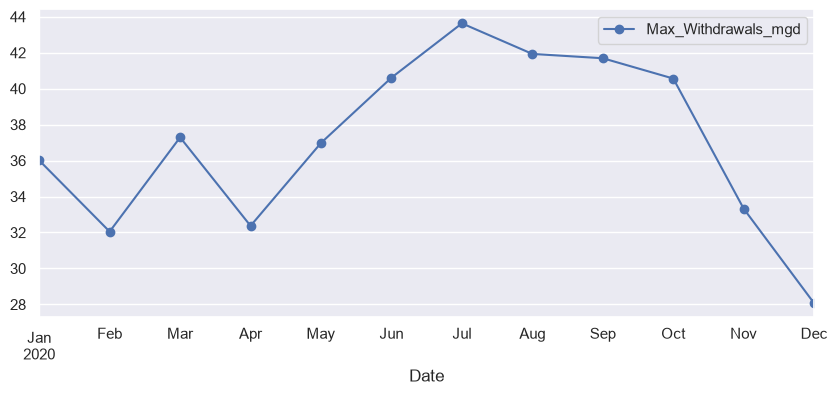

In [9]:
# 3.2.2 Plot the data
the_df.plot(kind='line',x='Date',y='Max_Withdrawals_mgd',figsize=(10,4),marker='o');

### 3.3 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

In [10]:
# 3.3.1 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020
the_df = scrape_withdrawals("03-92-020", 2020)

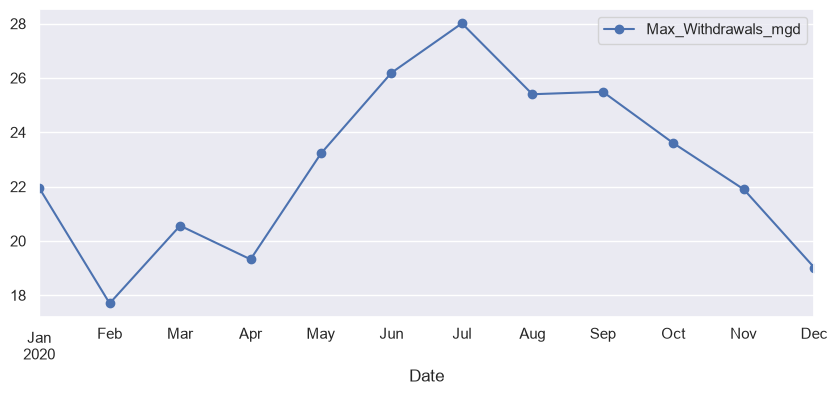

In [11]:
# 3.3.2 Plot the Cary data
the_df.plot(kind='line',x='Date',y='Max_Withdrawals_mgd',figsize=(10,4),marker='o');

### 3.4 Examine monthy max discharge from 2020-2025
* Use list comprehension (or other methods) to produce a list of dataframes, one for each year in 2020 to 2025
* Concatenate these dataframes into a single one including data for all years
* Create a line plot of max monthly discharge across the full timespan (x-axis labels do not have to be months)

In [12]:
# 3.4.1 Generate a list of the dataframes
#Set the years we want to scrape, and the facility
the_years = range(2020, 2026)
PWSID_ID = "03-32-010"

#Use list comprehension to capture the result of applying the function to our range of years
the_dfs = [scrape_withdrawals(PWSID_ID, year, pause=1) for year in the_years]


# 3.4.2 Combine them into a single dataframe
the_df = pd.concat(the_dfs, ignore_index=True)

In [13]:
# 3.4.3 Plot
#Extract values for plotting
the_system = the_df.loc[0,'Water_System_Name']
the_pwsid = the_df.loc[0,'PWSID']
start_date = the_df['Date'].min()
end_date = the_df['Date'].max()

#Create the facetgrid 
g = sns.relplot(
    data=the_df,
    x="Date",
    y="Max_Withdrawals_mgd",
    kind="line",
    aspect=3,
    marker='o'
)

#Set the axis labels and the limits of the x-axis
g.set(
    xlabel="Date", 
    ylabel="Withdrawal (mgd)",
    xlim=(start_date, end_date),
    ylim=(0,the_df['Max_Withdrawals_mgd'].max()*1.1)
)

#Set titles: "suptitle" is a larger "super" title
g.figure.suptitle(
    f"{the_system} - {the_pwsid}",,
    fontweight="bold",
    fontsize=14,
    y=1.05 #Place it a bit higher, to make space for the title below
)

#Title is a smaller title
g.ax.set_title(
    f"Water usage data: {start_date.year}-{end_date.year}",
    fontsize=11,
    pad = 2
);

SyntaxError: invalid syntax (132998192.py, line 28)